# Two-components Phase Exploration Visualizations

This notebook focuses on `two_components/outputs/phase_exploration/exploration_ensemble.csv`.
It compares the best (`min J_m`) and worst (`max J_m`) exploration runs against observed data.

## 1) Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
## 2) Import model setup and load data

In [3]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

from reactive_transport.simulation_options_2 import simulateDualPorosity


def load_data(csv_path):
    df = pd.read_csv(csv_path)
    weights = df["weight"].to_numpy()
    mask = weights.astype(bool)
    t_true = df["Time_hr"].to_numpy()[mask]
    c_true = df["C_corr_mgL"].to_numpy()[mask]
    return t_true, c_true


def modelRELAP(t, mrt, pec):
    frac_retard = 1.0
    bckgrnd_conc = 0.0
    inj_concs = np.array([7.0, 0.0], dtype=float)
    inj_durs = np.cumsum(np.array([1.5], dtype=float))
    dpParam = 0
    matrix_retardation = 1.0
    recRatio = 0.0
    wsCoef = 0.0
    return simulateDualPorosity(
        mrt,
        pec,
        frac_retard,
        t,
        bckgrnd_conc,
        inj_concs,
        inj_durs,
        dpParam,
        matrix_retardation,
        recRatio=recRatio,
        wsCoef=wsCoef,
        delay_time=0,
    )


def modelRELAP2(t, mrt1, mrt2, pec1, pec2, fr1, fr2):
    c1 = modelRELAP(t, mrt1, pec1)
    c2 = modelRELAP(t, mrt2, pec2)
    return fr1 * c1 + fr2 * c2


exploration_csv = repo_root / "two_components/outputs/phase_exploration/exploration_ensemble.csv"
ensemble = pd.read_csv(exploration_csv)
t_true, c_true = load_data(str(repo_root / "data/data.csv"))

best_row = ensemble.loc[ensemble["J_m"].idxmin()]
worst_row = ensemble.loc[ensemble["J_m"].idxmax()]

## 1) Observed data vs best-fit model curves (mean + 95% band)

Uses the **top N exploration runs** (lowest `J_m`). For each run, the forward model gives a full curve `C(t)`. Stacking those curves gives a **mean prediction** and **2.5–97.5%** percentile band (shown like a GPR mean with uncertainty). This is uncertainty **across comparable good fits**, not a GP fit to the observations.

In [4]:
N_best = 1024
elite = ensemble.nsmallest(N_best, "J_m")

t_plot = np.linspace(0.01, 130, 250)

curves_mix = []
curves_c1 = []
curves_c2 = []
for _, row in elite.iterrows():
    mrt1 = row["best_MRT1"]
    mrt2 = row["best_MRT2"]
    pec1 = row["best_Pe1"]
    pec2 = row["best_Pe2"]
    fr1 = row["best_fr1"]
    fr2 = row["best_fr2"]
    c1 = np.asarray(modelRELAP(t_plot, mrt1, pec1), dtype=float)
    c2 = np.asarray(modelRELAP(t_plot, mrt2, pec2), dtype=float)
    curves_c1.append(fr1 * c1)
    curves_c2.append(fr2 * c2)
    curves_mix.append(fr1 * c1 + fr2 * c2)

curves_mix = np.vstack(curves_mix)
curves_c1 = np.vstack(curves_c1)
curves_c2 = np.vstack(curves_c2)




In [5]:
def band_stats(curves_arr):
    mean_y = np.mean(curves_arr, axis=0)
    lo_y = np.percentile(curves_arr, 2.5, axis=0)
    hi_y = np.percentile(curves_arr, 97.5, axis=0)
    return mean_y, lo_y, hi_y


mean_mix, lo_mix, hi_mix = band_stats(curves_mix)
mean_1, lo_1, hi_1 = band_stats(curves_c1)
mean_2, lo_2, hi_2 = band_stats(curves_c2)

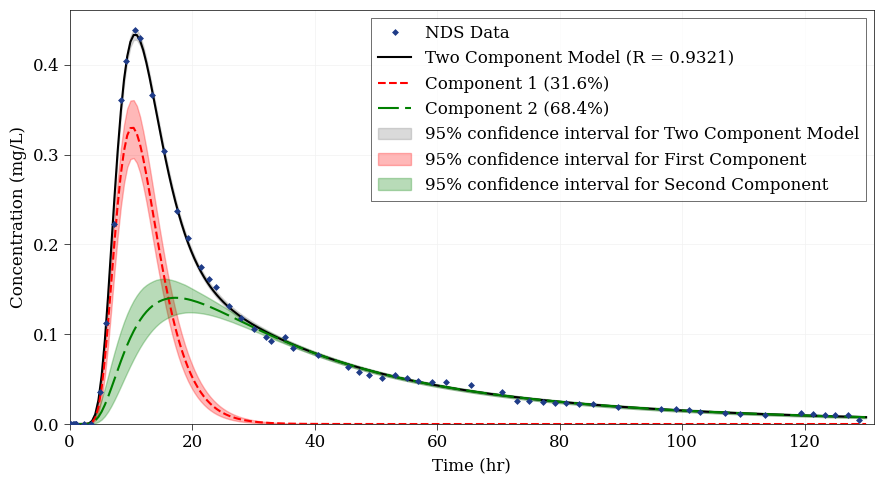

In [6]:
# Journal-style figure (Times New Roman 11 pt; Excel-like 0.25 pt grid/spines, 1 pt curve lines)
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"  # white ~5% toward black (Excel-style major grid)

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    h_ci_mix = ax.fill_between(t_plot, lo_mix, hi_mix, color="0.35", alpha=0.22)
    h_line_mix, = ax.plot(t_plot, mean_mix, color="black", linewidth=_pt)

    h_ci_c1 = ax.fill_between(t_plot, lo_1, hi_1, color="red", alpha=0.28)
    h_line_c1, = ax.plot(t_plot, mean_1, color="red", linewidth=_pt, linestyle="--")

    h_ci_c2 = ax.fill_between(t_plot, lo_2, hi_2, color="green", alpha=0.28)
    h_line_c2, = ax.plot(t_plot, mean_2, color="green", linewidth=_pt, linestyle=(0, (10, 3)))

    # markersize=3 ≈ 3 pt marker (Excel-style); edge matches fill color
    h_nds, = ax.plot(
        t_true,
        c_true,
        linestyle="None",
        marker="D",
        markersize=3,
        markerfacecolor="#1f3c88",
        markeredgecolor="#1f3c88",
        markeredgewidth=_pt_hair,
        zorder=5,
    )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("Concentration (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    x_hi = max(float(np.max(t_plot)), float(np.max(t_true)))
    y_hi = float(
        np.nanmax(
            [
                hi_mix.max(),
                hi_1.max(),
                hi_2.max(),
                float(np.max(c_true)),
            ]
        )
    )
    ax.set_xlim(0, x_hi * 1.01)
    ax.set_ylim(0, y_hi * 1.05)

    # Mean fr weights across the same elite runs as the curves (requires prep cell with `elite`)
    fr1_mean = float(np.mean(elite["best_fr1"].to_numpy()))
    fr2_mean = float(np.mean(elite["best_fr2"].to_numpy()))
    den = fr1_mean + fr2_mean
    pct1 = 100.0 * fr1_mean / den if den > 0 else 0.0
    pct2 = 100.0 * fr2_mean / den if den > 0 else 0.0
    R_sum = fr1_mean + fr2_mean

    leg_handles = [
        h_nds,
        h_line_mix,
        h_line_c1,
        h_line_c2,
        h_ci_mix,
        h_ci_c1,
        h_ci_c2,
    ]
    leg_labels = [
        "NDS Data",
        f"Two Component Model (R = {R_sum:.4f})",
        f"Component 1 ({pct1:.1f}%)",
        f"Component 2 ({pct2:.1f}%)",
        "95% confidence interval for Two Component Model",
        "95% confidence interval for First Component",
        "95% confidence interval for Second Component",
    ]
    leg = ax.legend(
        leg_handles,
        leg_labels,
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fancybox=False,
    )
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # Uncomment to save: no outer figure stroke; tight crop (pad_inches=0)
    fig.savefig(
        "ensemble_mixture_components.pdf",
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.25
    )

    plt.show()


In [7]:
# Add R2 for each run (all observed points) and write it back to the exploration ensemble CSV.
from reactive_transport.metrics_options import calcR2

r2_values = []
for _, row in ensemble.iterrows():
    c_pred = modelRELAP2(
        t_true,
        row["best_MRT1"],
        row["best_MRT2"],
        row["best_Pe1"],
        row["best_Pe2"],
        row["best_fr1"],
        row["best_fr2"],
    )
    r2_values.append(calcR2(c_pred, c_true))

ensemble["R2"] = np.asarray(r2_values, dtype=float)
ensemble.to_csv(exploration_csv, index=False)

print(f"Updated R2 column in: {exploration_csv}")
print(ensemble[["run_idx", "J_m", "R2"]].head())


Updated R2 column in: /mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/two_components/outputs/phase_exploration/exploration_ensemble.csv
   run_idx       J_m        R2
0        1  0.032658  0.998593
1        2  0.034102  0.998558
2        3  0.033832  0.998523
3        4  0.032566  0.998633
4        5  0.034437  0.998449


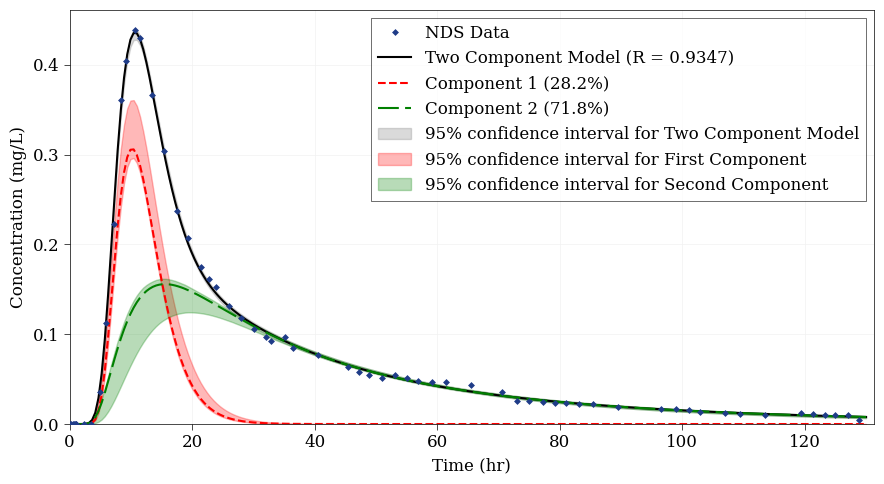

In [8]:
# Journal-style figure: BEST run curves + CI bands
# (keeps CI envelopes from the ensemble, replaces mean lines with best-fit lines)

best_elite = elite.iloc[0]

c1_best = best_elite["best_fr1"] * np.asarray(
    modelRELAP(t_plot, best_elite["best_MRT1"], best_elite["best_Pe1"]), dtype=float
)
c2_best = best_elite["best_fr2"] * np.asarray(
    modelRELAP(t_plot, best_elite["best_MRT2"], best_elite["best_Pe2"]), dtype=float
)
mix_best = c1_best + c2_best

_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    h_ci_mix = ax.fill_between(t_plot, lo_mix, hi_mix, color="0.35", alpha=0.22)
    h_line_mix, = ax.plot(t_plot, mix_best, color="black", linewidth=_pt)

    h_ci_c1 = ax.fill_between(t_plot, lo_1, hi_1, color="red", alpha=0.28)
    h_line_c1, = ax.plot(t_plot, c1_best, color="red", linewidth=_pt, linestyle="--")

    h_ci_c2 = ax.fill_between(t_plot, lo_2, hi_2, color="green", alpha=0.28)
    h_line_c2, = ax.plot(t_plot, c2_best, color="green", linewidth=_pt, linestyle=(0, (10, 3)))

    h_nds, = ax.plot(
        t_true,
        c_true,
        linestyle="None",
        marker="D",
        markersize=3,
        markerfacecolor="#1f3c88",
        markeredgecolor="#1f3c88",
        markeredgewidth=_pt_hair,
        zorder=5,
    )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("Concentration (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    x_hi = max(float(np.max(t_plot)), float(np.max(t_true)))
    y_hi = float(
        np.nanmax(
            [
                hi_mix.max(),
                hi_1.max(),
                hi_2.max(),
                float(np.max(c_true)),
            ]
        )
    )
    ax.set_xlim(0, x_hi * 1.01)
    ax.set_ylim(0, y_hi * 1.05)

    fr1_best = float(best_elite["best_fr1"])
    fr2_best = float(best_elite["best_fr2"])
    den_best = fr1_best + fr2_best
    pct1_best = 100.0 * fr1_best / den_best if den_best > 0 else 0.0
    pct2_best = 100.0 * fr2_best / den_best if den_best > 0 else 0.0
    R_sum_best = fr1_best + fr2_best

    leg_handles = [
        h_nds,
        h_line_mix,
        h_line_c1,
        h_line_c2,
        h_ci_mix,
        h_ci_c1,
        h_ci_c2,
    ]
    leg_labels = [
        "NDS Data",
        f"Two Component Model (R = {R_sum_best:.4f})",
        f"Component 1 ({pct1_best:.1f}%)",
        f"Component 2 ({pct2_best:.1f}%)",
        "95% confidence interval for Two Component Model",
        "95% confidence interval for First Component",
        "95% confidence interval for Second Component",
    ]
    leg = ax.legend(
        leg_handles,
        leg_labels,
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fancybox=False,
    )
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    fig.savefig(
        "bestrun_mixture_components_with_ci.pdf",
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.25,
    )

    plt.show()


In [10]:
ensemble.sort_values(by='J_m', ascending=True)

,run_idx,seed,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,J_m,R2
969,970,1070,11.454518,48.341635,15.378135,2.025713,0.263344,0.671376,0.031154,0.998767
754,755,855,11.451426,47.762613,15.407555,2.135057,0.267543,0.663745,0.031193,0.998767
96,97,197,11.490801,49.393359,15.310949,1.971368,0.261325,0.683476,0.031247,0.998710
1021,1022,1122,11.555293,49.502084,14.728900,2.153909,0.284885,0.654075,0.031309,0.998737
88,89,189,11.465096,50.026407,15.746960,1.898323,0.258696,0.686609,0.031352,0.998730
...,...,...,...,...,...,...,...,...,...,...
56,57,157,11.589527,48.588057,14.557639,2.456719,0.300136,0.613619,0.035336,0.998236
993,994,1094,11.486598,46.239644,14.628152,2.712796,0.304958,0.616282,0.035349,0.998496
459,460,560,11.786952,47.433310,13.602667,2.800039,0.328746,0.576399,0.035438,0.998402
511,512,612,11.965399,50.673159,12.529385,2.689986,0.347152,0.579194,0.035477,0.998208


In [11]:
ensemble.describe()

,run_idx,seed,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,J_m,R2
count,1024.00000,1024.00000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,512.50000,612.50000,11.595119,49.236469,14.385596,2.283753,0.294678,0.637403,0.033033,0.998564
std,295.74764,295.74764,0.118754,1.555517,0.741822,0.213107,0.021794,0.026250,0.000848,0.000102
min,1.00000,101.00000,11.289658,44.558905,12.529385,1.746895,0.230560,0.568407,0.031154,0.998183
25%,256.75000,356.75000,11.512514,48.166082,13.864725,2.135089,0.280041,0.617867,0.032421,0.998501
50%,512.50000,612.50000,11.592368,49.343360,14.301313,2.282142,0.296067,0.635637,0.032968,0.998580
75%,768.25000,868.25000,11.676383,50.286855,14.849822,2.431611,0.309043,0.654497,0.033570,0.998637
max,1024.00000,1124.00000,11.990757,53.753453,17.309234,2.898093,0.355212,0.723126,0.036048,0.998767


In [12]:
# Load exploitation (best-per-basin) and exploration data without overwriting existing variables
best_basin_df2 = pd.read_csv("../two_components/outputs/phase_exploitation/best_refined_per_basin.csv")
explore_ens_df2 = pd.read_csv("../two_components/outputs/phase_exploration/exploration_ensemble.csv")

param_cols2 = ["best_MRT1", "best_MRT2", "best_Pe1", "best_Pe2", "best_fr1", "best_fr2"]

# Pick the lowest-objective refined row as requested
best_basin_row2 = best_basin_df2.sort_values("best_J", ascending=True).iloc[0].copy()

# Group in memory: exploration ensemble + best refined-per-basin rows
combined_ens_df2 = pd.concat(
    [
        explore_ens_df2[param_cols2].copy(),
        best_basin_df2[param_cols2].copy(),
    ],
    ignore_index=True,
)

print(f"best_refined_per_basin rows: {len(best_basin_df2)}")
print(f"exploration_ensemble rows:   {len(explore_ens_df2)}")
print(f"combined in-memory rows:     {len(combined_ens_df2)}")
print("lowest best_J row basin_id:", int(best_basin_row2["basin_id"]))

best_refined_per_basin rows: 24
exploration_ensemble rows:   1024
combined in-memory rows:     1048
lowest best_J row basin_id: 19


In [13]:
# Simulate curves for refined-only and grouped datasets (new variables only)
t_plot2 = np.linspace(0.01, 130, 250)


def band_stats2(arr):
    arr = np.asarray(arr, dtype=float)
    return (
        np.percentile(arr, 50, axis=0),
        np.percentile(arr, 2.5, axis=0),
        np.percentile(arr, 97.5, axis=0),
    )


# Refined-only ensemble bands
curves_ref_12, curves_ref_22, curves_ref_mix2 = [], [], []
for _, row2 in best_basin_df2.iterrows():
    c1r2 = row2["best_fr1"] * np.asarray(modelRELAP(t_plot2, row2["best_MRT1"], row2["best_Pe1"]), dtype=float)
    c2r2 = row2["best_fr2"] * np.asarray(modelRELAP(t_plot2, row2["best_MRT2"], row2["best_Pe2"]), dtype=float)
    curves_ref_12.append(c1r2)
    curves_ref_22.append(c2r2)
    curves_ref_mix2.append(c1r2 + c2r2)

mean_ref_12, lo_ref_12, hi_ref_12 = band_stats2(curves_ref_12)
mean_ref_22, lo_ref_22, hi_ref_22 = band_stats2(curves_ref_22)
mean_ref_mix2, lo_ref_mix2, hi_ref_mix2 = band_stats2(curves_ref_mix2)

# Grouped ensemble bands (exploration + best_refined_per_basin)
curves_grp_12, curves_grp_22, curves_grp_mix2 = [], [], []
for _, row2 in combined_ens_df2.iterrows():
    c1g2 = row2["best_fr1"] * np.asarray(modelRELAP(t_plot2, row2["best_MRT1"], row2["best_Pe1"]), dtype=float)
    c2g2 = row2["best_fr2"] * np.asarray(modelRELAP(t_plot2, row2["best_MRT2"], row2["best_Pe2"]), dtype=float)
    curves_grp_12.append(c1g2)
    curves_grp_22.append(c2g2)
    curves_grp_mix2.append(c1g2 + c2g2)

mean_grp_12, lo_grp_12, hi_grp_12 = band_stats2(curves_grp_12)
mean_grp_22, lo_grp_22, hi_grp_22 = band_stats2(curves_grp_22)
mean_grp_mix2, lo_grp_mix2, hi_grp_mix2 = band_stats2(curves_grp_mix2)

# Best-fit line from lowest best_J row in best_refined_per_basin.csv
c1_best_basin2 = best_basin_row2["best_fr1"] * np.asarray(
    modelRELAP(t_plot2, best_basin_row2["best_MRT1"], best_basin_row2["best_Pe1"]), dtype=float
)
c2_best_basin2 = best_basin_row2["best_fr2"] * np.asarray(
    modelRELAP(t_plot2, best_basin_row2["best_MRT2"], best_basin_row2["best_Pe2"]), dtype=float
)
mix_best_basin2 = c1_best_basin2 + c2_best_basin2

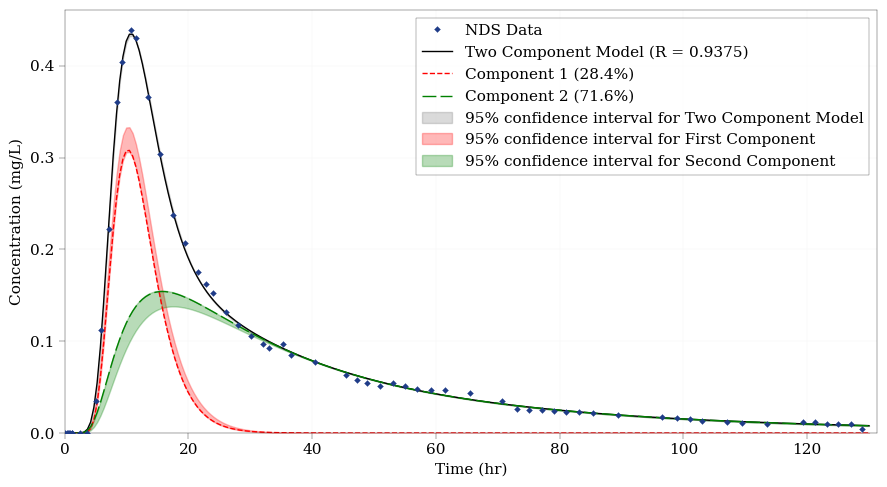

In [14]:
# Journal-style plot: lowest-best_J line + refined-per-basin CI bands
_pt2 = 1.0
_pt_hair2 = 0.25
font_size2 = 11
_grid_gray2 = "#F2F2F2"

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size2,
        "axes.labelsize": font_size2,
        "xtick.labelsize": font_size2,
        "ytick.labelsize": font_size2,
        "legend.fontsize": font_size2,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig2, ax2 = plt.subplots(figsize=(9, 5), facecolor="white")
    ax2.set_facecolor("white")
    ax2.set_axisbelow(True)
    ax2.grid(True, which="major", linewidth=_pt_hair2, color=_grid_gray2, linestyle="-")

    h_ci_mix2 = ax2.fill_between(t_plot2, lo_ref_mix2, hi_ref_mix2, color="0.35", alpha=0.22)
    h_line_mix2, = ax2.plot(t_plot2, mix_best_basin2, color="black", linewidth=_pt2)

    h_ci_c12 = ax2.fill_between(t_plot2, lo_ref_12, hi_ref_12, color="red", alpha=0.28)
    h_line_c12, = ax2.plot(t_plot2, c1_best_basin2, color="red", linewidth=_pt2, linestyle="--")

    h_ci_c22 = ax2.fill_between(t_plot2, lo_ref_22, hi_ref_22, color="green", alpha=0.28)
    h_line_c22, = ax2.plot(t_plot2, c2_best_basin2, color="green", linewidth=_pt2, linestyle=(0, (10, 3)))

    h_nds2, = ax2.plot(
        t_true,
        c_true,
        linestyle="None",
        marker="D",
        markersize=3,
        markerfacecolor="#1f3c88",
        markeredgecolor="#1f3c88",
        markeredgewidth=_pt_hair2,
        zorder=5,
    )

    ax2.set_xlabel("Time (hr)")
    ax2.set_ylabel("Concentration (mg/L)")

    for side2 in ax2.spines:
        ax2.spines[side2].set_visible(True)
        ax2.spines[side2].set_linewidth(_pt_hair2)
        ax2.spines[side2].set_color("black")

    ax2.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair2,
        colors="black",
        top=False,
        right=False,
    )

    x_hi2 = max(float(np.max(t_plot2)), float(np.max(t_true)))
    y_hi2 = float(np.nanmax([hi_ref_mix2.max(), hi_ref_12.max(), hi_ref_22.max(), float(np.max(c_true))]))
    ax2.set_xlim(0, x_hi2 * 1.01)
    ax2.set_ylim(0, y_hi2 * 1.05)

    fr1_best2 = float(best_basin_row2["best_fr1"])
    fr2_best2 = float(best_basin_row2["best_fr2"])
    den_best2 = fr1_best2 + fr2_best2
    pct1_best2 = 100.0 * fr1_best2 / den_best2 if den_best2 > 0 else 0.0
    pct2_best2 = 100.0 * fr2_best2 / den_best2 if den_best2 > 0 else 0.0
    R_sum_best2 = fr1_best2 + fr2_best2

    leg2 = ax2.legend(
        [h_nds2, h_line_mix2, h_line_c12, h_line_c22, h_ci_mix2, h_ci_c12, h_ci_c22],
        [
            "NDS Data",
            f"Two Component Model (R = {R_sum_best2:.4f})",
            f"Component 1 ({pct1_best2:.1f}%)",
            f"Component 2 ({pct2_best2:.1f}%)",
            "95% confidence interval for Two Component Model",
            "95% confidence interval for First Component",
            "95% confidence interval for Second Component",
        ],
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fancybox=False,
    )
    leg2.get_frame().set_linewidth(_pt_hair2)
    leg2.get_frame().set_edgecolor("black")

    fig2.tight_layout()
    fig2.patch.set_linewidth(0)
    fig2.patch.set_edgecolor("none")

    fig2.savefig(
        "best_refined_per_basin_lowestJ_with_refined_ci.pdf",
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.25,
    )

    plt.show()

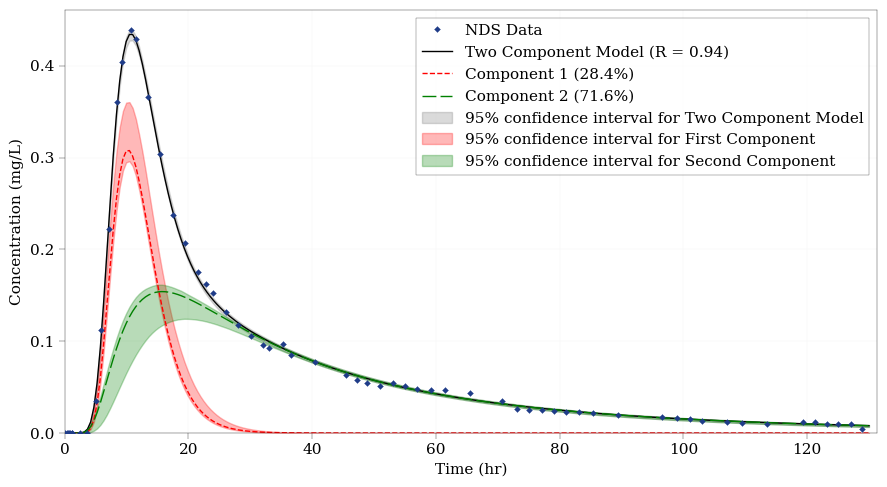

In [17]:
# Journal-style plot: lowest-best_J line + grouped (exploration + refined) CI bands
with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size2,
        "axes.labelsize": font_size2,
        "xtick.labelsize": font_size2,
        "ytick.labelsize": font_size2,
        "legend.fontsize": font_size2,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig3, ax3 = plt.subplots(figsize=(9, 5), facecolor="white")
    ax3.set_facecolor("white")
    ax3.set_axisbelow(True)
    ax3.grid(True, which="major", linewidth=_pt_hair2, color=_grid_gray2, linestyle="-")

    h_ci_mix3 = ax3.fill_between(t_plot2, lo_grp_mix2, hi_grp_mix2, color="0.35", alpha=0.22)
    h_line_mix3, = ax3.plot(t_plot2, mix_best_basin2, color="black", linewidth=_pt2)

    h_ci_c13 = ax3.fill_between(t_plot2, lo_grp_12, hi_grp_12, color="red", alpha=0.28)
    h_line_c13, = ax3.plot(t_plot2, c1_best_basin2, color="red", linewidth=_pt2, linestyle="--")

    h_ci_c23 = ax3.fill_between(t_plot2, lo_grp_22, hi_grp_22, color="green", alpha=0.28)
    h_line_c23, = ax3.plot(t_plot2, c2_best_basin2, color="green", linewidth=_pt2, linestyle=(0, (10, 3)))

    h_nds3, = ax3.plot(
        t_true,
        c_true,
        linestyle="None",
        marker="D",
        markersize=3,
        markerfacecolor="#1f3c88",
        markeredgecolor="#1f3c88",
        markeredgewidth=_pt_hair2,
        zorder=5,
    )

    ax3.set_xlabel("Time (hr)")
    ax3.set_ylabel("Concentration (mg/L)")

    for side3 in ax3.spines:
        ax3.spines[side3].set_visible(True)
        ax3.spines[side3].set_linewidth(_pt_hair2)
        ax3.spines[side3].set_color("black")

    ax3.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair2,
        colors="black",
        top=False,
        right=False,
    )

    x_hi3 = max(float(np.max(t_plot2)), float(np.max(t_true)))
    y_hi3 = float(np.nanmax([hi_grp_mix2.max(), hi_grp_12.max(), hi_grp_22.max(), float(np.max(c_true))]))
    ax3.set_xlim(0, x_hi3 * 1.01)
    ax3.set_ylim(0, y_hi3 * 1.05)

    fr1_best3 = float(best_basin_row2["best_fr1"])
    fr2_best3 = float(best_basin_row2["best_fr2"])
    den_best3 = fr1_best3 + fr2_best3
    pct1_best3 = 100.0 * fr1_best3 / den_best3 if den_best3 > 0 else 0.0
    pct2_best3 = 100.0 * fr2_best3 / den_best3 if den_best3 > 0 else 0.0
    R_sum_best3 = fr1_best3 + fr2_best3

    leg3 = ax3.legend(
        [h_nds3, h_line_mix3, h_line_c13, h_line_c23, h_ci_mix3, h_ci_c13, h_ci_c23],
        [
            "NDS Data",
            f"Two Component Model (R = {R_sum_best3:.2f})",
            f"Component 1 ({pct1_best3:.1f}%)",
            f"Component 2 ({pct2_best3:.1f}%)",
            "95% confidence interval for Two Component Model",
            "95% confidence interval for First Component",
            "95% confidence interval for Second Component",
        ],
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fancybox=False,
    )
    leg3.get_frame().set_linewidth(_pt_hair2)
    leg3.get_frame().set_edgecolor("black")

    fig3.tight_layout()
    fig3.patch.set_linewidth(0)
    fig3.patch.set_edgecolor("none")

    fig3.savefig(
        "best_refined_lowestJ_with_grouped_explore_refined_ci.pdf",
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.25,
    )

    plt.show()

In [19]:
combined_ens_df2['R'] = combined_ens_df2['best_fr1'] + combined_ens_df2['best_fr2']
# combined_ens_df2.sort_values(by='R', ascending=True)
combined_ens_df2.describe()

,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,R
count,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000
mean,11.593116,49.230904,14.401211,2.279132,0.294175,0.638008,0.932182
std,0.118396,1.538846,0.743013,0.213159,0.021861,0.026319,0.009841
min,11.289658,44.558905,12.529385,1.746895,0.230560,0.568407,0.905145
25%,11.507000,48.189145,13.875641,2.124187,0.278415,0.618158,0.925313
50%,11.589197,49.265929,14.323332,2.275988,0.295669,0.636398,0.932112
75%,11.674095,50.267228,14.881054,2.426704,0.308608,0.655628,0.938588
max,11.990757,53.753453,17.309234,2.898093,0.355212,0.723126,0.966870
